<a href="https://colab.research.google.com/github/gitmystuff/DTSC5502/blob/main/Module_10-GLMs/Module_10_In_Class_Activity_Pt_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 10 Activity

by Your Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5502 repository
* Save a Copy in Drive
* Remove Copy of
* Submit shared link in Canvas

## Logarithms and Euler's Number

### Logarithms

* Logarithms are the inverse of exponentials
* $10^3 = 1000$ and $log_{10}(1000) = 3$
* When data units need scaling
* Expressing large numbers
* $y = ax^n$ is like $log(y) = n log(x) + log(a)$
* Reduces finding n to a linear equation
* $y = a e^{bx}$ is like $log(y) = bx + log(a)$
* Addition and subtraction
* Multiplication and division

Types of logarithms

* Binary: computer science (0s and 1s), music theory (distance between stacked notes)
* Natural (Euler): chemistry, economics, comparing age of a dog to human
* Common (10): sound, pH, electricity, light

Sources

* https://math.stackexchange.com/questions/35810/intuitive-use-of-logarithms
* https://www.snexplores.org/article/explainer-what-are-logarithms-exponents


Examples:

* $log_{10}(10)=1$
* $log_{10}(100)=2$
* etc
* numpy log10
* numpy log default is natural log

In [8]:
import pandas as pd
import numpy as np

def exponent_logarithm_table(base, powers):
  """
  Generates a table of exponents and logarithms for a given base and powers.

  Args:
    base: The base of the exponent and logarithm.
    powers: A list of powers to calculate.

  Returns:
    A pandas DataFrame with columns for 'Power', 'Exponent', and 'Logarithm'.
  """

  data = {'Power': powers,
          'Base**Power': [base**power for power in powers],
          'Logarithm': [np.log(base**power) / np.log(base) for power in powers],
          'Using Exp': [np.exp(np.log(power)) for power in powers]
          }
  print(f'Base: {base}')
  df = pd.DataFrame(data)
  return df

# Example usage:
base = 2
powers = [1, 2, 3, 4, 5]
table = exponent_logarithm_table(base, powers)
print(table)
print()

base = 10
powers = [1, 2, 3, 4, 5]
table = exponent_logarithm_table(base, powers)
print(table)

Base: 2
   Power  Base**Power  Logarithm  Using Exp
0      1            2        1.0        1.0
1      2            4        2.0        2.0
2      3            8        3.0        3.0
3      4           16        4.0        4.0
4      5           32        5.0        5.0

Base: 10
   Power  Base**Power  Logarithm  Using Exp
0      1           10        1.0        1.0
1      2          100        2.0        2.0
2      3         1000        3.0        3.0
3      4        10000        4.0        4.0
4      5       100000        5.0        5.0


In [11]:
# interesting properties
import numpy as np

x = 7
print(np.exp(np.log(x)))
print(np.log(np.exp(x)))

6.999999999999999
7.0


In [ ]:
# # get the data
# import pandas as pd

# moores = pd.read_csv('https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv', header=None)


In [ ]:
# x = np.exp(np.log(4))

In [ ]:
# 2300 / 1e10

In [ ]:
# apply log to transistors


In [ ]:
# np.log(2300)

### Euler's Number (e)

* $e = 1 + 1/1 + 1/2 + 1/3! + 1/4! + ... + 1/n!$
* Compound interest (like exponential growth) $FV = PV e^{rt}
* where FV is Future Value, PV is Present Value, e is Euler's Number, r is Interest Rate Compounded, and t is time

In [ ]:
# $1000 investment with 2% interest over 3 years
import numpy as np

1000 * np.exp(0.02 * 3)

In [ ]:
# Investing $1000 with 10 percent continuous compound interest over 40 years
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 40, 40)

# continuous
y = 1000 * np.exp(.1*x)
plt.scatter(x, y, label='continuous')
print(max(y))

# discrete
y = 1000 * (1 + .1)**(x)
plt.scatter(x, y, label='discrete')
print(max(y))
plt.legend();

In [ ]:
# 10 percent compound interest over 50 years and annual contributions of $2400 (monthly $200 contributions)
# https://math.stackexchange.com/questions/4475485/compound-interest-including-contributions
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 40, 40)

y = (1000*(1.1)**x) + (2400/.1)*((1.1)**x - 1)
plt.scatter(x, y);
print((1000*(1.1)**40) + (2400/.1)*((1.1)**40 - 1))

## Link Functions

Allows the linear model to be related to the response variable by transforming the output of the response to fit the model boundaries.

$\eta$ = link

* linear: $\eta (\mu) = \mu$
* logistic: $\eta(\mu) = log(\mu/(1-\mu))$
* poisson: $\eta(\mu) = log(\mu)$

The link function is a crucial component of a Generalized Linear Model (GLM). It provides the connection between the linear predictor (a linear combination of the predictors) and the expected value of the response variable.  Think of it as a translator that allows you to model different types of response variables within a linear framework.

Here's a breakdown of what the link function does and why it's important:

**1. Linear Predictor**

In a GLM, you have a linear predictor, which is simply a weighted sum of your predictor variables (features). It looks like this:

  `linear predictor = b0 + b1*x1 + b2*x2 + ...`

where:

* `b0`, `b1`, `b2`, etc. are the coefficients estimated by the model.
* `x1`, `x2`, etc. are the predictor variables.

**2.  Connecting to the Response**

The link function takes this linear predictor and transforms it to match the expected value of the response variable. This is necessary because the response variable might not have a linear relationship with the predictors and might have specific constraints.

**3.  Examples of Link Functions**

* **Identity link:** `g(μ) = μ` (no transformation) - Used for continuous data with a normal distribution (simple linear regression).
* **Logit link:** `g(μ) = log(μ / (1 - μ))` - Used for binary data (logistic regression). It maps probabilities (between 0 and 1) to a range from negative to positive infinity.
* **Log link:** `g(μ) = log(μ)` - Used for count data (Poisson regression) or continuous positive data. It ensures the predicted values are positive.
* **Inverse link:** `g(μ) = 1 / μ` - Used when the response is inversely proportional to the linear predictor.

**4.  Why is the Link Function Important?**

* **Flexibility:** It allows GLMs to model various types of response variables (continuous, binary, count, etc.) within a unified framework.
* **Interpretability:** It provides a meaningful way to interpret the relationship between the predictors and the response variable on a suitable scale.
* **Statistical Properties:**  It ensures that the model's predictions satisfy the properties of the chosen response distribution.

**5. Choosing the Link Function**

The choice of link function depends on the nature of your response variable and the assumptions you're making about its distribution. Here's a general guideline:

* **Normally distributed:** Identity link
* **Positive skewed data:** Log link
* **Binary data:** Logit link
* **Count data:** Log link

**In summary:**

The link function is a key component of a GLM that connects the linear predictor to the expected value of the response variable. It allows you to model different types of response variables and ensures that the model's predictions are meaningful and statistically sound.


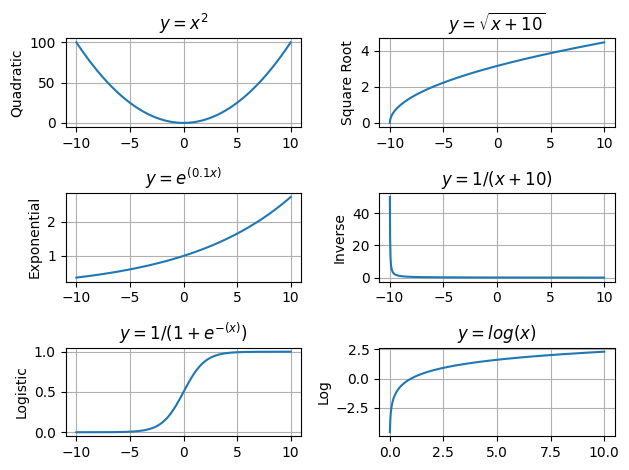

In [ ]:
# link functions
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

fig = plt.figure()
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)

x = np.linspace(-10, 10, 1000)

y = x ** 2
ax1.grid()
ax1.plot(x, y)
ax1.title.set_text(r'$y=x^2$')
# ax1.title.set_text('y=x^2')
ax1.set_ylabel('Quadratic')

y = np.sqrt(x+10)
ax2.grid()
ax2.plot(x, y)
ax2.title.set_text(r'$y=\sqrt{x+10}$')
# ax2.title.set_text('y=sqrt(x)')
ax2.set_ylabel('Square Root')

y = np.e**(0.1*x)
ax3.grid()
ax3.plot(x, y)
ax3.title.set_text(r'$y=e^{(0.1x)}$')
# ax3.title.set_text('y=e^(0.1x)')
ax3.set_ylabel('Exponential')

y = 1/(x+10)
ax4.grid()
ax4.plot(x, y)
ax4.title.set_text(r'$y=1/(x+10)$')
# ax4.title.set_text('y=1/(x+10)')
ax4.set_ylabel('Inverse')

y = 1/(1 + np.e**-(x))
ax5.grid()
ax5.plot(x, y)
ax5.title.set_text(r'$y=1/(1+e^{-(x)})$')
# ax5.title.set_text('y=1/(1+e^-(x)')
ax5.set_ylabel('Logistic')

y = np.log(x)
ax6.grid()
ax6.plot(x, y)
ax6.title.set_text(r'$y=log(x)$')
# ax6.title.set_text('y=log(x)')
ax6.set_ylabel('Log')

plt.tight_layout();

## Family

The `family` parameter in a Generalized Linear Model (GLM) is crucial because it specifies the **probability distribution** of your response variable (the variable you're trying to predict). This distribution determines the relationship between the linear predictor (a combination of predictors and coefficients) and the expected value of the response.

Here's a breakdown of why the `family` parameter is important and how it works:

**1.  Connecting the Linear Predictor to the Response**

In a GLM, the link function connects the linear predictor to the response variable. However, the link function alone doesn't fully define the relationship. The `family` parameter specifies the distribution of the response, which, in conjunction with the link function, determines how the linear predictor is related to the expected value of the response.

**2.  Common Families and Their Uses**

Here are some common families used in GLMs:

* **Gaussian (Normal):**  Used for continuous data that is normally distributed. This is the default family for many GLM implementations.
* **Binomial:** Used for binary data (e.g., success/failure, presence/absence) or count data where the number of trials is fixed.
* **Poisson:** Used for count data where the events occur independently at a constant rate (e.g., the number of customers arriving at a store per hour).
* **Gamma:** Used for continuous positive data that is skewed (e.g., income, waiting times).
* **Inverse Gaussian:**  Used for continuous positive data with a specific type of skewness.

**3.  Choosing the Right Family**

The choice of family depends on the nature of your response variable and the assumptions you're willing to make about its distribution. Here's a general guideline:

* **Normally distributed:** Gaussian family
* **Skewed positive data:** Gamma or Inverse Gaussian family
* **Binary data:** Binomial family
* **Count data:** Poisson family

**4.  Example: `statsmodels` in Python**

In `statsmodels`, you specify the family using the `family` argument in the `GLM` class. For example:

```python
import statsmodels.api as sm

# Fit a GLM with a Gaussian family and identity link (default)
model = sm.GLM(y, X, family=sm.families.Gaussian())
```

This code specifies a Gaussian family for the response variable `y`. You can change the family to `sm.families.Binomial()`, `sm.families.Poisson()`, etc., depending on your data.

**Key Takeaways**

* The `family` parameter in a GLM determines the probability distribution of the response variable.
* It works in conjunction with the link function to define the relationship between the linear predictor and the response.
* Choosing the appropriate family is crucial for building a valid and meaningful GLM.
* The choice of family should be based on the nature of your response variable and the assumptions you're making about its distribution.


### Simple Linear Regression

The link function for simple linear regression is the **identity function**.

Here's why:

* **GLMs and Link Functions:** Generalized Linear Models (GLMs) extend traditional linear regression to accommodate various types of response variables (continuous, binary, counts, etc.).  A key component of a GLM is the *link function*, which establishes a connection between the linear predictor (the familiar $mx + b$ in simple linear regression) and the expected value of the response variable.

* **Identity Function:** The identity function is simply a function that returns its input unchanged.  Mathematically, it's represented as  $f(x) = x$.

* **Simple Linear Regression:** In simple linear regression, we're modeling a continuous response variable with a normal distribution.  The expected value of the response variable is directly equal to the linear predictor.  In other words, we don't need any transformation to map the linear predictor to the expected value.  This "no transformation" is precisely what the identity function accomplishes. The identity link function in simple linear regression preserves the linear relationship between the predictor and the response variable. It's the simplest and most direct way to model this type of relationship within the GLM framework.

**In summary:** The identity link function in simple linear regression implies that the predicted value from the linear equation ($mx + b$) is directly used as the expected value of the response variable.


### Quadratic Function

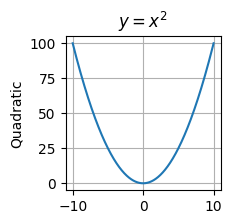

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(2,2))
x = np.linspace(-10, 10, 1000)
y = x ** 2
plt.grid()
plt.plot(x, y)
plt.title(r'$y=x^2$')
plt.ylabel('Quadratic')
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          83.691
Method:                          IRLS   Log-Likelihood:                -361.73
Date:                Fri, 25 Oct 2024   Deviance:                       8118.0
Time:                        12:07:43   Pearson chi2:                 8.12e+03
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6617      1.372     -1.211      0.2

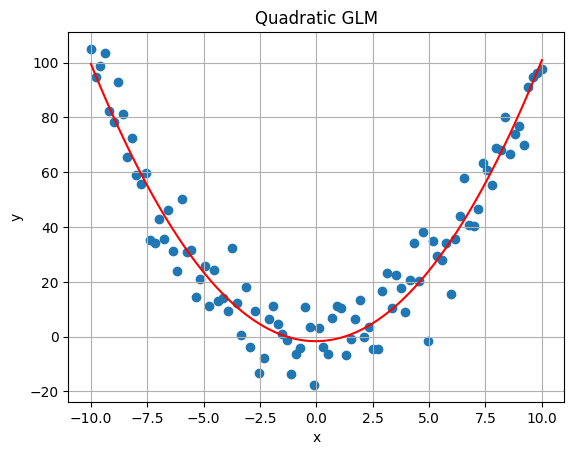

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# generate data and set variables
title = 'Quadratic GLM'
family = sm.families.Gaussian()
link_function = lambda x: x**2
np.random.seed(42)
x = np.linspace(-10, 10, 100)
y = link_function(x) + np.random.normal(0, 10, 100)  # Add some noise

# GLM Model building
X = np.column_stack((x, link_function(x)))
X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.GLM(y, X, family=family).fit()
predictions = model.predict(X)
print(model.summary())

# Plot the data and the fitted curve (predictions)
plt.scatter(x, y)
plt.plot(x, predictions, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{title}')
plt.grid(True)
plt.show()

### Square Root Function

x values must be non-negative for sqrt

<ipython-input-10-a06af158205f>:19: RuntimeWarning: invalid value encountered in sqrt
  predictions = np.sqrt(y_pred_transformed) # Take the square root


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          7.5358
Method:                          IRLS   Log-Likelihood:                -241.87
Date:                Fri, 25 Oct 2024   Deviance:                       738.51
Time:                        12:35:58   Pearson chi2:                     739.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9905
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.9088      0.275     36.096      0.0

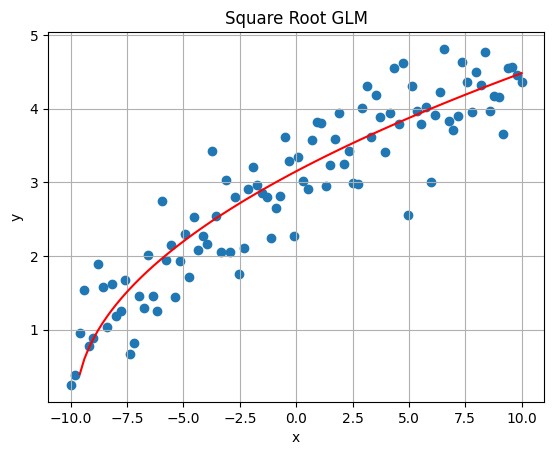

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate data and set variables
np.random.seed(42)
title = 'Square Root GLM'
family = sm.families.Gaussian()
link_function = lambda x: np.sqrt(x+10)
x = np.linspace(-10, 10, 100)  # x values must be non-negative for sqrt
y = link_function(x) + np.random.normal(0, 0.5, 100)  # Add some noise

# GLM modeling
X = sm.add_constant(x)  # Add a constant for the intercept
# statsmodels doesn't directly support a square root link function for the Gaussian family
y_transformed = y ** 2  # Square the y values
model = sm.GLM(y_transformed, X, family=family).fit()
y_pred_transformed = model.predict(X) # make predictions (on the transformed scale)
predictions = np.sqrt(y_pred_transformed) # Take the square root
print(model.summary())

# Plot the data and the fitted curve (predictions on the original scale)
plt.scatter(x, y)
plt.plot(x, predictions, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{title}')
plt.grid(True)
plt.show()

Why y transformation is necessary:

* **Desired Relationship:** The code aims to model a square root relationship between `x` and `y`, as indicated by the `link_function = lambda x: np.sqrt(x+10)`. This means that `y` should increase roughly as the square root of `x`.

* **Limitations of `statsmodels`:**  While `statsmodels` provides a flexible framework for GLMs, it doesn't directly support a square root link function for the Gaussian family.

* **Transformation as a Solution:** To overcome this limitation, the code applies a transformation to the response variable (`y`) *before* fitting the GLM. By squaring `y` (`y_transformed = y ** 2`), the relationship between `x` and `y_transformed` becomes approximately linear.

* **Fitting a Linear Model:** Now that the relationship is linear on the transformed scale, a standard GLM with an identity link function can be used to model the data effectively.

* **Back-Transformation:** After fitting the model and making predictions on the transformed scale (`y_pred_transformed`), the code applies the inverse transformation (square root) to get predictions on the original scale of `y` (`predictions = np.sqrt(y_pred_transformed)`).

**In essence:**

Transforming `y` allows you to model a non-linear (square root) relationship using a linear model (GLM with identity link). It's a common technique in statistics when the desired relationship doesn't directly fit into the available model framework.

This approach demonstrates the flexibility of GLMs and how transformations can be used to extend their capabilities to model various types of relationships.


### Exponential Function

family=sm.families.Gaussian(link=sm.families.links.log())

### Inverse Function



### Logistic Function

### Log Function